In [12]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

BASE     = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}

In [13]:
def load_tasks():
    rows = []
    for f in sorted(BASE.glob('**/*.json')):
        d    = json.loads(f.read_text())
        reps = d['repetitions']
        rows.append({
            'W':        d['W'],
            'dataset':  d['dataset'],
            'topology': d.get('topology_name', 'fc'),
            'qid':      d['question_id'],
            'accuracy': float(np.mean([r['correct'] for r in reps])),
        })
    return pd.DataFrame(rows)

df = load_tasks()
df['difficulty'] = df.groupby(['dataset', 'qid'])['accuracy'].transform('mean')
print(f'Loaded {len(df)} records')

Loaded 420 records


---
# Two independent ranking axes

| Axis | Held fixed | Varied | Rank range |
|------|-----------|--------|------------|
| **Memory** | `(dataset, qid, topology)` | W ∈ {1, 2, 5} | 1–3 |
| **Topology** | `(dataset, qid, W)` | {fc, star} | 1–2 |

Ranking is done within each group so the two axes are never mixed.

---
# Part A — Memory Axis (W=1 vs W=2 vs W=5)

Topology held fixed.  For each `(dataset, qid, topology)` the three W values are ranked 1–3.

In [14]:
mem_df = (
    df
    .groupby(['dataset', 'qid', 'topology'], group_keys=False)
    .apply(lambda g: g.assign(
        rank_W=g['accuracy'].rank(ascending=False, method='average').astype(float)
    ))
    .reset_index(drop=True)
)

print('Mean rank of each W (1=best, 3=worst):')
print(
    mem_df.groupby(['dataset', 'topology', 'W'])['rank_W']
    .mean().round(3).to_string()
)

Mean rank of each W (1=best, 3=worst):
dataset      topology  W
gpqa         fc        1    1.871
                       2    2.014
                       5    2.114
             star      1    1.971
                       2    2.000
                       5    2.029
hiddenbench  fc        1    2.157
                       2    1.914
                       5    1.929
             star      1    2.100
                       2    2.057
                       5    1.843


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_60061/423319658.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(


### A1 — Rank heatmap per problem
Rows = W values, columns = problems sorted easy→hard.  Green=rank 1, red=rank 3.

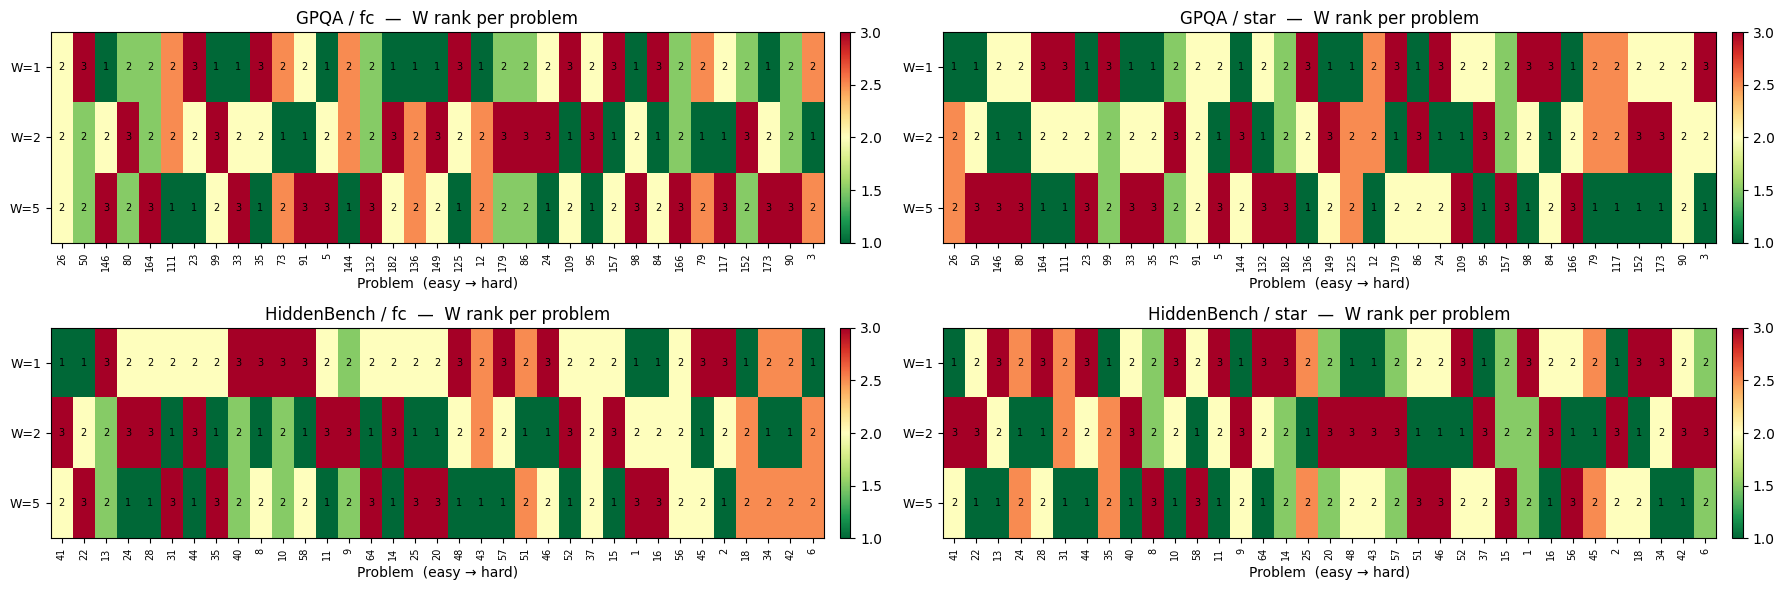

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 6))
cmap = plt.cm.RdYlGn_r

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = mem_df[(mem_df['dataset'] == ds) & (mem_df['topology'] == topo)]
        qids_sorted = (
            sub.groupby('qid')['difficulty'].first()
            .sort_values(ascending=False).index.tolist()
        )
        pivot = (
            sub.pivot_table(index='W', columns='qid', values='rank_W')
            .reindex(index=W_VALUES, columns=qids_sorted)
        )
        im = ax.imshow(pivot.values, aspect='auto', cmap=cmap,
                       vmin=1, vmax=3, interpolation='nearest')
        for r in range(len(W_VALUES)):
            for c in range(len(qids_sorted)):
                ax.text(c, r, f'{pivot.values[r,c]:.0f}',
                        ha='center', va='center', fontsize=7)
        ax.set_yticks(range(len(W_VALUES)))
        ax.set_yticklabels([f'W={w}' for w in W_VALUES], fontsize=9)
        ax.set_xticks(range(len(qids_sorted)))
        ax.set_xticklabels(qids_sorted, rotation=90, fontsize=7)
        ax.set_xlabel('Problem  (easy → hard)')
        ax.set_title(f'{DS_LABELS[ds]} / {topo}  —  W rank per problem')
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

plt.tight_layout()
plt.show()

### A2 — Rank distribution (stacked bars)
How often does each W land in rank 1, 2, 3 across problems?

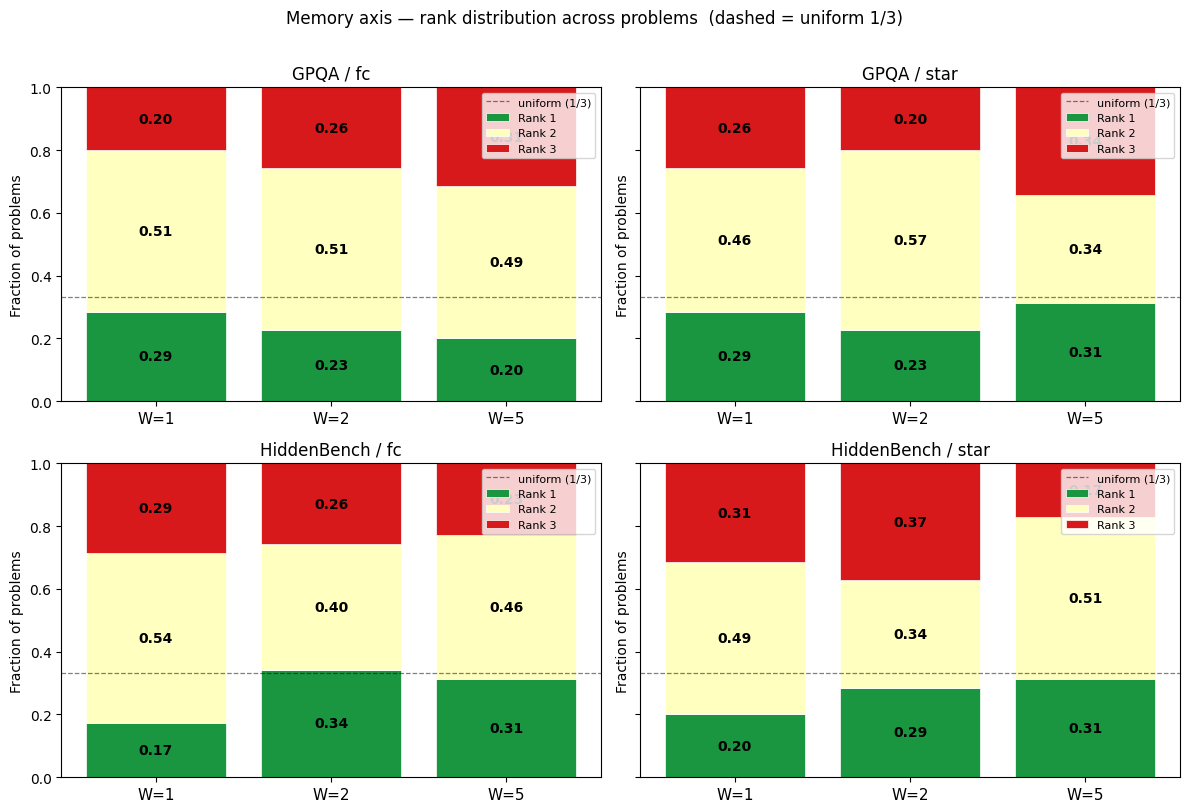

In [16]:
rank_colors = {1: '#1a9641', 2: '#ffffbf', 3: '#d7191c'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = mem_df[(mem_df['dataset'] == ds) & (mem_df['topology'] == topo)]
        n_q = sub['qid'].nunique()
        bottom = np.zeros(len(W_VALUES))

        for rank_val in [1, 2, 3]:
            fracs = [
                (sub[(sub['W'] == w) & (sub['rank_W'].round() == rank_val)].shape[0] / n_q)
                for w in W_VALUES
            ]
            ax.bar(range(len(W_VALUES)), fracs, bottom=bottom,
                   color=rank_colors[rank_val], edgecolor='white', linewidth=0.5,
                   label=f'Rank {rank_val}')
            for i, f in enumerate(fracs):
                if f > 0.05:
                    ax.text(i, bottom[i] + f/2, f'{f:.2f}',
                            ha='center', va='center', fontsize=10, fontweight='bold')
            bottom += np.array(fracs)

        ax.axhline(1/3, color='black', linestyle='--', linewidth=0.9, alpha=0.5,
                   label='uniform (1/3)')
        ax.set_xticks(range(len(W_VALUES)))
        ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=11)
        ax.set_ylabel('Fraction of problems')
        ax.set_ylim(0, 1)
        ax.set_title(f'{DS_LABELS[ds]} / {topo}')
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Memory axis — rank distribution across problems  (dashed = uniform 1/3)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### A3 — Bump chart
Each line = one W value; each column = one problem.  Top = best rank.  
Line crossings show where the ordering is inconsistent.

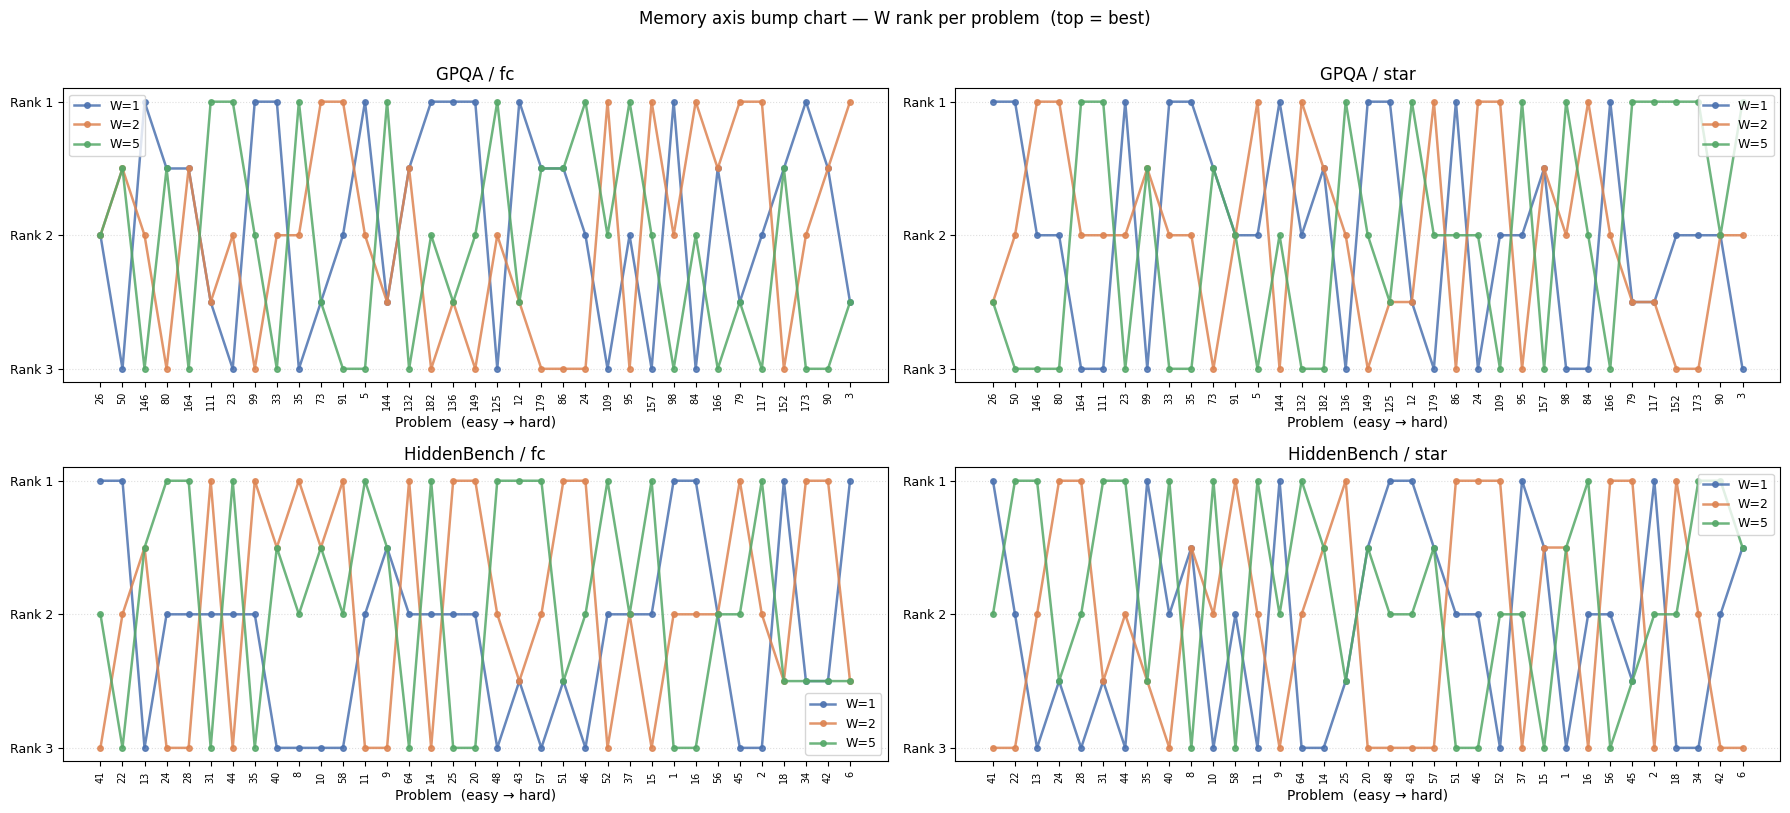

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = mem_df[(mem_df['dataset'] == ds) & (mem_df['topology'] == topo)]
        qids_sorted = (
            sub.groupby('qid')['difficulty'].first()
            .sort_values(ascending=False).index.tolist()
        )
        pivot = (
            sub.pivot_table(index='W', columns='qid', values='rank_W')
            .reindex(index=W_VALUES, columns=qids_sorted)
        )
        for w in W_VALUES:
            ax.plot(range(len(qids_sorted)), pivot.loc[w].values,
                    color=W_COLORS[w], linewidth=1.8, alpha=0.85,
                    marker='o', markersize=4, label=f'W={w}')
        ax.set_xticks(range(len(qids_sorted)))
        ax.set_xticklabels(qids_sorted, rotation=90, fontsize=7)
        ax.set_yticks([1, 2, 3])
        ax.set_yticklabels(['Rank 1', 'Rank 2', 'Rank 3'], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Problem  (easy → hard)')
        ax.set_title(f'{DS_LABELS[ds]} / {topo}')
        ax.legend(fontsize=9)
        ax.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle('Memory axis bump chart — W rank per problem  (top = best)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### A4 — Statistical tests

In [18]:
print('=== Friedman test: W ranking consistent across problems? ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub   = mem_df[(mem_df['dataset'] == ds) & (mem_df['topology'] == topo)]
        pivot = sub.pivot_table(index='qid', columns='W', values='rank_W').reindex(columns=W_VALUES)
        stat, p = sp_stats.friedmanchisquare(*[pivot[w].values for w in W_VALUES])
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  χ²={stat:.3f}  p={p:.4f}')

print()
print('=== Pairwise Wilcoxon signed-rank: W pairs ===')
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    for topo in TOPOS:
        sub   = mem_df[(mem_df['dataset'] == ds) & (mem_df['topology'] == topo)]
        pivot = sub.pivot_table(index='qid', columns='W', values='rank_W').reindex(columns=W_VALUES)
        print(f'  {topo}:')
        for a, b in combinations(W_VALUES, 2):
            stat, p = sp_stats.wilcoxon(pivot[a].values, pivot[b].values, alternative='two-sided')
            sig = '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))
            print(f'    W={a} (μrank={pivot[a].mean():.3f}) vs W={b} (μrank={pivot[b].mean():.3f})  p={p:.4f} {sig}')

=== Friedman test: W ranking consistent across problems? ===
  GPQA         fc     χ²=1.217  p=0.5443
  GPQA         star   χ²=0.065  p=0.9680
  HiddenBench  fc     χ²=1.492  p=0.4743
  HiddenBench  star   χ²=1.453  p=0.4836

=== Pairwise Wilcoxon signed-rank: W pairs ===

GPQA
  fc:
    W=1 (μrank=1.871) vs W=2 (μrank=2.014)  p=0.5787 ns
    W=1 (μrank=1.871) vs W=5 (μrank=2.114)  p=0.2626 ns
    W=2 (μrank=2.014) vs W=5 (μrank=2.114)  p=0.7189 ns
  star:
    W=1 (μrank=1.971) vs W=2 (μrank=2.000)  p=0.7955 ns
    W=1 (μrank=1.971) vs W=5 (μrank=2.029)  p=0.8867 ns
    W=2 (μrank=2.000) vs W=5 (μrank=2.029)  p=0.8830 ns

HiddenBench
  fc:
    W=1 (μrank=2.157) vs W=2 (μrank=1.914)  p=0.1796 ns
    W=1 (μrank=2.157) vs W=5 (μrank=1.929)  p=0.3397 ns
    W=2 (μrank=1.914) vs W=5 (μrank=1.929)  p=0.8803 ns
  star:
    W=1 (μrank=2.100) vs W=2 (μrank=2.057)  p=0.8494 ns
    W=1 (μrank=2.100) vs W=5 (μrank=1.843)  p=0.1428 ns
    W=2 (μrank=2.057) vs W=5 (μrank=1.843)  p=0.6210 ns


---
# Part B — Topology Axis (FC vs Star)

W held fixed.  For each `(dataset, qid, W)` the two topologies are ranked 1–2.

In [19]:
topo_df = (
    df
    .groupby(['dataset', 'qid', 'W'], group_keys=False)
    .apply(lambda g: g.assign(
        rank_T=g['accuracy'].rank(ascending=False, method='average').astype(float)
    ))
    .reset_index(drop=True)
)

print('FC win / tie / star win rate per (dataset, W):')
rows = []
for ds in DATASETS:
    for w in W_VALUES:
        sub  = topo_df[(topo_df['dataset'] == ds) & (topo_df['W'] == w)]
        fc_r = sub[sub['topology'] == 'fc']['rank_T']
        rows.append({
            'dataset': ds, 'W': w,
            'fc_wins':   (fc_r < 1.5).mean(),
            'ties':      (fc_r == 1.5).mean(),
            'star_wins': (fc_r > 1.5).mean(),
        })
print(pd.DataFrame(rows).round(3).to_string(index=False))

FC win / tie / star win rate per (dataset, W):
    dataset  W  fc_wins  ties  star_wins
       gpqa  1    0.400 0.114      0.486
       gpqa  2    0.514 0.057      0.429
       gpqa  5    0.514 0.029      0.457
hiddenbench  1    0.400 0.200      0.400
hiddenbench  2    0.457 0.086      0.457
hiddenbench  5    0.457 0.000      0.543


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_60061/3961948571.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(


### B1 — Rank heatmap per problem
Rows = topologies, columns = problems sorted easy→hard.  Green = rank 1 (wins), red = rank 2 (loses).

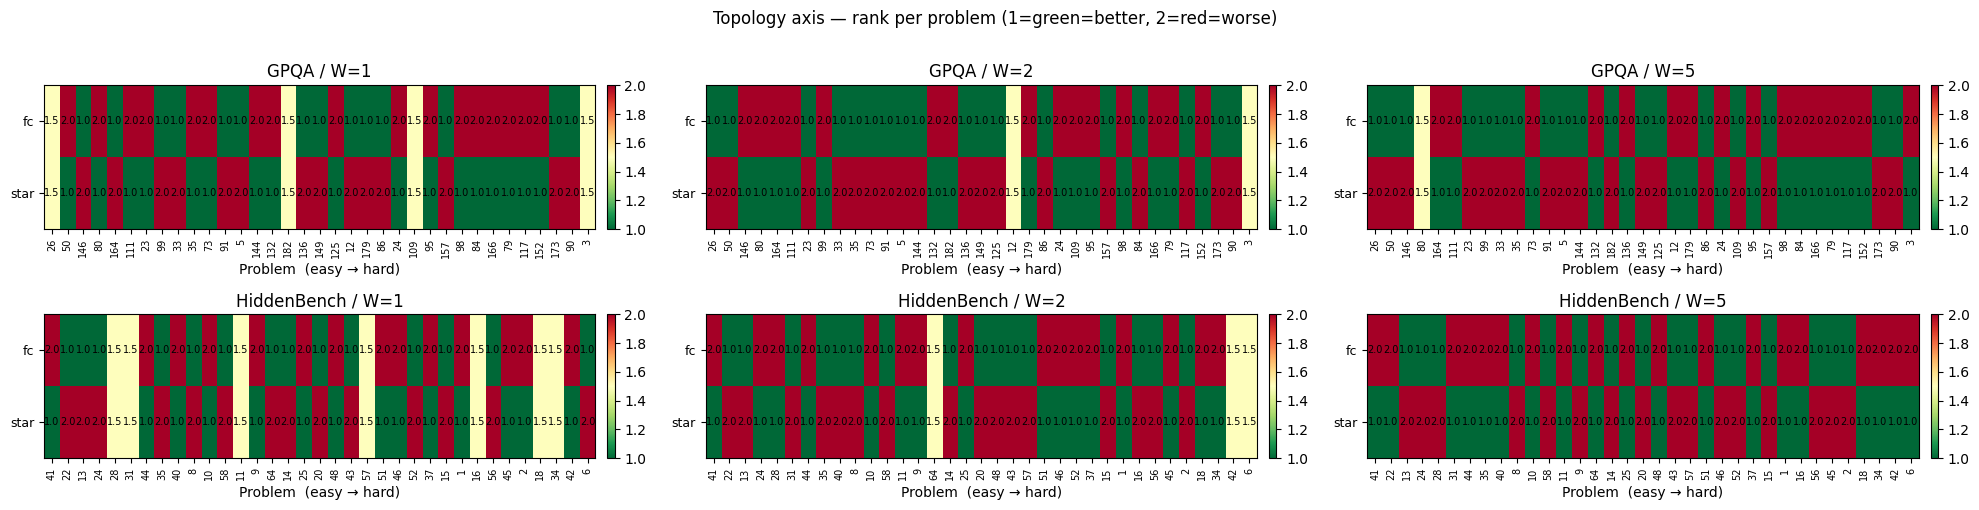

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 5))
cmap2 = plt.cm.RdYlGn_r

for col, w in enumerate(W_VALUES):
    for row, ds in enumerate(DATASETS):
        ax  = axes[row][col]
        sub = topo_df[(topo_df['dataset'] == ds) & (topo_df['W'] == w)]
        qids_sorted = (
            sub.groupby('qid')['difficulty'].first()
            .sort_values(ascending=False).index.tolist()
        )
        pivot = (
            sub.pivot_table(index='topology', columns='qid', values='rank_T')
            .reindex(index=TOPOS, columns=qids_sorted)
        )
        im = ax.imshow(pivot.values, aspect='auto', cmap=cmap2,
                       vmin=1, vmax=2, interpolation='nearest')
        for r in range(len(TOPOS)):
            for c in range(len(qids_sorted)):
                ax.text(c, r, f'{pivot.values[r,c]:.1f}',
                        ha='center', va='center', fontsize=7)
        ax.set_yticks(range(len(TOPOS)))
        ax.set_yticklabels(TOPOS, fontsize=9)
        ax.set_xticks(range(len(qids_sorted)))
        ax.set_xticklabels(qids_sorted, rotation=90, fontsize=7)
        ax.set_xlabel('Problem  (easy → hard)')
        ax.set_title(f'{DS_LABELS[ds]} / W={w}')
        plt.colorbar(im, ax=ax, fraction=0.06, pad=0.02)

fig.suptitle('Topology axis — rank per problem (1=green=better, 2=red=worse)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### B2 — Win rate bars
Across the 35 problems: how often does FC beat Star, tie, or lose?

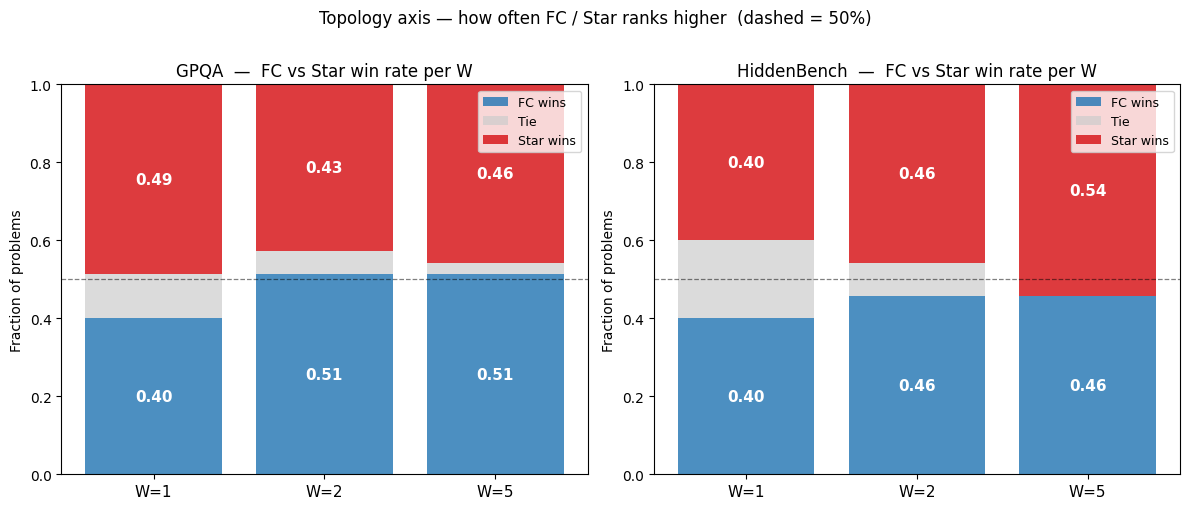

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ds in zip(axes, DATASETS):
    fc_wins, ties, star_wins = [], [], []
    n_q = topo_df[topo_df['dataset'] == ds]['qid'].nunique()

    for w in W_VALUES:
        sub  = topo_df[(topo_df['dataset'] == ds) & (topo_df['W'] == w)]
        fc_r = sub[sub['topology'] == 'fc']['rank_T']
        fc_wins.append((fc_r < 1.5).mean())
        ties.append((fc_r == 1.5).mean())
        star_wins.append((fc_r > 1.5).mean())

    x = np.arange(len(W_VALUES))
    ax.bar(x, fc_wins,   color=T_COLORS['fc'],   alpha=0.85, label='FC wins')
    ax.bar(x, ties,      bottom=fc_wins, color='#cccccc', alpha=0.7, label='Tie')
    bottom_star = [f + t for f, t in zip(fc_wins, ties)]
    ax.bar(x, star_wins, bottom=bottom_star,
           color=T_COLORS['star'], alpha=0.85, label='Star wins')

    for i, (fw, t, sw) in enumerate(zip(fc_wins, ties, star_wins)):
        if fw > 0.04:
            ax.text(i, fw/2, f'{fw:.2f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
        if sw > 0.04:
            ax.text(i, bottom_star[i] + sw/2, f'{sw:.2f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')

    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=11)
    ax.set_ylabel('Fraction of problems')
    ax.set_ylim(0, 1)
    ax.set_title(f'{DS_LABELS[ds]}  —  FC vs Star win rate per W')
    ax.legend(fontsize=9)

fig.suptitle('Topology axis — how often FC / Star ranks higher  (dashed = 50%)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### B3 — Statistical tests

In [22]:
print('=== Sign / Wilcoxon test: FC vs Star per (dataset, W) ===')
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    for w in W_VALUES:
        sub  = topo_df[(topo_df['dataset'] == ds) & (topo_df['W'] == w)]
        fc   = sub[sub['topology'] == 'fc'].set_index('qid')['accuracy']
        star = sub[sub['topology'] == 'star'].set_index('qid')['accuracy']
        diff = fc - star
        n_fc   = (diff > 0).sum()
        n_star = (diff < 0).sum()
        n_tie  = (diff == 0).sum()
        binom  = sp_stats.binomtest(n_fc, n_fc + n_star, p=0.5, alternative='two-sided')
        diff_nz = diff[diff != 0]
        w_stat, w_p = sp_stats.wilcoxon(diff_nz, alternative='two-sided') if len(diff_nz) > 0 else (np.nan, np.nan)
        sig = '***' if w_p < .001 else ('**' if w_p < .01 else ('*' if w_p < .05 else 'ns'))
        print(f'  W={w}  fc>{n_fc}  star>{n_star}  tie={n_tie}  '
              f'binom_p={binom.pvalue:.4f}  wilcoxon_p={w_p:.4f} {sig}')

=== Sign / Wilcoxon test: FC vs Star per (dataset, W) ===

GPQA
  W=1  fc>14  star>17  tie=4  binom_p=0.7201  wilcoxon_p=0.8063 ns
  W=2  fc>18  star>15  tie=2  binom_p=0.7283  wilcoxon_p=0.9359 ns
  W=5  fc>18  star>16  tie=1  binom_p=0.8642  wilcoxon_p=0.7581 ns

HiddenBench
  W=1  fc>14  star>14  tie=7  binom_p=1.0000  wilcoxon_p=0.8108 ns
  W=2  fc>16  star>16  tie=3  binom_p=1.0000  wilcoxon_p=0.8223 ns
  W=5  fc>16  star>19  tie=0  binom_p=0.7359  wilcoxon_p=0.6582 ns


---
## Summary

In [23]:
print('=== MEMORY AXIS: mean rank of W (1=best, 3=worst) ===')
print(
    mem_df.groupby(['dataset', 'topology', 'W'])['rank_W']
    .agg(['mean', 'median']).round(3).to_string()
)

print()
print('=== TOPOLOGY AXIS: FC win rate across problems ===')
rows = []
for ds in DATASETS:
    for w in W_VALUES:
        sub  = topo_df[(topo_df['dataset'] == ds) & (topo_df['W'] == w)]
        fc_r = sub[sub['topology'] == 'fc']['rank_T']
        rows.append({
            'dataset': ds, 'W': w,
            'fc_win_rate':   round((fc_r < 1.5).mean(), 3),
            'tie_rate':      round((fc_r == 1.5).mean(), 3),
            'star_win_rate': round((fc_r > 1.5).mean(), 3),
        })
print(pd.DataFrame(rows).to_string(index=False))

=== MEMORY AXIS: mean rank of W (1=best, 3=worst) ===
                         mean  median
dataset     topology W               
gpqa        fc       1  1.871     1.5
                     2  2.014     2.0
                     5  2.114     2.0
            star     1  1.971     2.0
                     2  2.000     2.0
                     5  2.029     2.0
hiddenbench fc       1  2.157     2.0
                     2  1.914     2.0
                     5  1.929     2.0
            star     1  2.100     2.0
                     2  2.057     2.0
                     5  1.843     2.0

=== TOPOLOGY AXIS: FC win rate across problems ===
    dataset  W  fc_win_rate  tie_rate  star_win_rate
       gpqa  1        0.400     0.114          0.486
       gpqa  2        0.514     0.057          0.429
       gpqa  5        0.514     0.029          0.457
hiddenbench  1        0.400     0.200          0.400
hiddenbench  2        0.457     0.086          0.457
hiddenbench  5        0.457     0.000       

---
# Part C — Mixed-Effects Logistic Regression

Per-problem ranking (Parts A & B) is dominated by noise at n=30 reps/condition.
This part pools all **35 problems × 30 reps = 1,050 binary outcomes** per cell using
a **GEE (Generalized Estimating Equations)** model:

- Outcome: `correct` (0/1 per repetition)
- Fixed effect: W (categorical, W=1 reference) or topology (star reference)
- Cluster: `qid` — each problem is its own cluster with exchangeable within-problem correlation

This gives proper effect estimates and CIs that account for between-problem variance.

In [24]:
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

def load_reps():
    rows = []
    for f in sorted(BASE.glob('**/*.json')):
        d    = json.loads(f.read_text())
        W    = d['W']
        ds   = d['dataset']
        topo = d.get('topology_name', 'fc')
        qid  = d['question_id']
        for rep in d['repetitions']:
            rows.append({
                'W':        W,
                'dataset':  ds,
                'topology': topo,
                'qid':      qid,
                'correct':  int(rep['correct']),
            })
    reps = pd.DataFrame(rows)
    reps['W_cat']    = pd.Categorical(reps['W'].astype(str), categories=['1','2','5'])
    reps['topo_cat'] = pd.Categorical(reps['topology'],      categories=['star','fc'])
    reps['qid_int']  = reps.groupby('dataset')['qid'].transform(lambda x: pd.factorize(x)[0])
    return reps

reps_df = load_reps()
print(f'Rep records: {len(reps_df):,}')
print(reps_df.groupby(['dataset','topology','W'])['correct'].agg(['sum','count','mean']).round(3).to_string())

Rep records: 12,600
                        sum  count   mean
dataset     topology W                   
gpqa        fc       1  527   1050  0.502
                     2  522   1050  0.497
                     5  532   1050  0.507
            star     1  499   1050  0.475
                     2  512   1050  0.488
                     5  502   1050  0.478
hiddenbench fc       1  314   1050  0.299
                     2  337   1050  0.321
                     5  337   1050  0.321
            star     1  319   1050  0.304
                     2  341   1050  0.325
                     5  345   1050  0.329


In [26]:
def fit_gee(sub, predictor):
    model = GEE(
        endog=sub['correct'],
        exog=pd.get_dummies(sub[predictor], drop_first=True).astype(float),
        groups=sub['qid_int'],
        family=Binomial(),
        cov_struct=Exchangeable(),
    )
    res = model.fit(maxiter=60)
    return res

def summarise_gee(res, predictor_labels):
    rows = []
    for name, label in zip(res.model.exog_names, ['intercept'] + predictor_labels):
        coef = res.params[name]
        ci   = res.conf_int().loc[name]
        p    = res.pvalues[name]
        or_  = np.exp(coef)
        or_lo, or_hi = np.exp(ci[0]), np.exp(ci[1])
        sig  = '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))
        rows.append({'term': label, 'coef': coef, 'OR': or_,
                     'OR_lo': or_lo, 'OR_hi': or_hi, 'p': p, 'sig': sig})
    return pd.DataFrame(rows)

print('=' * 65)
print('GEE — Memory axis: W effect on P(correct)')
print('Reference: W=1.  Exchangeable within-problem correlation.')
print('=' * 65)

gee_results_W = {}
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    for topo in TOPOS:
        sub = reps_df[(reps_df['dataset'] == ds) & (reps_df['topology'] == topo)].copy()
        res = fit_gee(sub, 'W_cat')
        summ = summarise_gee(res, ['W=2 vs W=1', 'W=5 vs W=1'])
        gee_results_W[(ds, topo)] = summ
        print(f'\n  {topo}:')
        print(summ[summ['term'] != 'intercept'][
            ['term','OR','OR_lo','OR_hi','p','sig']
        ].to_string(index=False))

print()
print('=' * 65)
print('GEE — Topology axis: FC vs Star effect on P(correct)')
print('Reference: star.  Exchangeable within-problem correlation.')
print('=' * 65)

gee_results_T = {}
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    for w in W_VALUES:
        sub = reps_df[(reps_df['dataset'] == ds) & (reps_df['W'] == w)].copy()
        res = fit_gee(sub, 'topo_cat')
        summ = summarise_gee(res, ['FC vs Star'])
        gee_results_T[(ds, w)] = summ
        row = summ[summ['term'] == 'FC vs Star'].iloc[0]
        print(f'  W={w}  OR={row.OR:.3f}  95%CI=[{row.OR_lo:.3f},{row.OR_hi:.3f}]  '
              f'p={row.p:.4f} {row.sig}')

GEE — Memory axis: W effect on P(correct)
Reference: W=1.  Exchangeable within-problem correlation.

GPQA

  fc:
      term       OR    OR_lo    OR_hi        p sig
W=2 vs W=1 1.019702 0.858253 1.211521 0.824434  ns

  star:
      term       OR    OR_lo    OR_hi        p sig
W=2 vs W=1 1.003988 0.874006 1.153301 0.955134  ns

HiddenBench

  fc:
      term       OR    OR_lo    OR_hi        p sig
W=2 vs W=1 1.033354 0.903562 1.181791 0.631859  ns

  star:
      term       OR    OR_lo    OR_hi        p sig
W=2 vs W=1 1.044472 0.896507 1.216858 0.576663  ns

GEE — Topology axis: FC vs Star effect on P(correct)
Reference: star.  Exchangeable within-problem correlation.

GPQA


IndexError: single positional indexer is out-of-bounds

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, DATASETS):
    y_labels, ors, lo_errs, hi_errs, colors = [], [], [], [], []

    for topo in TOPOS:
        summ = gee_results_W[(ds, topo)]
        for _, row in summ[summ['term'] != 'intercept'].iterrows():
            y_labels.append(f'{topo} / {row["term"]}')
            ors.append(row['OR'])
            lo_errs.append(row['OR'] - row['OR_lo'])
            hi_errs.append(row['OR_hi'] - row['OR'])
            colors.append(T_COLORS[topo])

    y = np.arange(len(y_labels))
    ax.barh(y, [o - 1 for o in ors], left=1,
            xerr=[lo_errs, hi_errs], color=colors, alpha=0.75,
            capsize=4, edgecolor='white', height=0.5)
    ax.axvline(1, color='black', linewidth=1.2, linestyle='--')
    for i, (o, lo, hi) in enumerate(zip(ors, lo_errs, hi_errs)):
        sig = '*' if (o - lo > 1 or o + hi < 1) else ''
        ax.text(max(o + hi, 1) + 0.01, i, f'{o:.2f}{sig}', va='center', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel('Odds ratio  (ref = W=1)')
    ax.set_title(f'{DS_LABELS[ds]} — memory effect (GEE)')
    ax.set_xlim(0.5, 2.0)

fig.suptitle('GEE: effect of W on P(correct) — OR > 1 means W beats W=1',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, ds in zip(axes, DATASETS):
    ors, lo_errs, hi_errs = [], [], []
    for w in W_VALUES:
        row = gee_results_T[(ds, w)][gee_results_T[(ds, w)]['term'] == 'FC vs Star'].iloc[0]
        ors.append(row['OR'])
        lo_errs.append(row['OR'] - row['OR_lo'])
        hi_errs.append(row['OR_hi'] - row['OR'])

    y = np.arange(len(W_VALUES))
    ax.barh(y, [o - 1 for o in ors], left=1,
            xerr=[lo_errs, hi_errs], color=T_COLORS['fc'], alpha=0.75,
            capsize=4, edgecolor='white', height=0.5)
    ax.axvline(1, color='black', linewidth=1.2, linestyle='--')
    for i, (o, lo, hi) in enumerate(zip(ors, lo_errs, hi_errs)):
        ax.text(max(o + hi, 1) + 0.01, i, f'{o:.2f}', va='center', fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels([f'W={w}' for w in W_VALUES], fontsize=10)
    ax.set_xlabel('Odds ratio  (ref = Star)')
    ax.set_title(f'{DS_LABELS[ds]} — topology effect (GEE)')
    ax.set_xlim(0.5, 2.0)

fig.suptitle('GEE: effect of FC vs Star on P(correct) — OR > 1 means FC beats Star',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()